# Chapter 5 — System Evaluation
### CyberSight AI · Equipment Detection & Identification Pipeline

This notebook produces all evaluation figures and tables for **Chapter 5** of the PFE thesis.

| Section | Evaluation |
|---------|------------|
| 5.1 | Test Dataset Overview |
| 5.2 | Equipment Classification Accuracy (Roboflow RF-DETR) |
| 5.3 | Pipeline Stage Latency Benchmark |
| 5.4 | VLM Brand Identification Accuracy (Groq Llama-4-Scout) |
| 5.5 | Spec Extraction Completeness |
| 5.6 | Summary Dashboard |

> **Note:** Sections 5.2 and 5.4 make live API calls. They may take 2–5 minutes to run.

In [1]:
import sys, os, time, json, re, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

# ── Path setup ────────────────────────────────────────────────────────────────
BACKEND_DIR = Path(os.getcwd()).parent
SESSIONS_DIR = BACKEND_DIR / "sessions"
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from dotenv import load_dotenv
load_dotenv(BACKEND_DIR / ".env")

print(f"Backend dir : {BACKEND_DIR}")
print(f"Sessions dir: {SESSIONS_DIR}")
print("Environment loaded.")

Backend dir : c:\Users\chahd\Desktop\DetectionAppPFE\backend
Sessions dir: c:\Users\chahd\Desktop\DetectionAppPFE\backend\sessions
Environment loaded.


---
## 5.1 — Test Dataset Overview
We use the **hero frames** produced by the real deployment sessions as our test set.
Each filename encodes the ground-truth class (e.g. `hero_2_air_conditioner.png`).

In [2]:
# ── Collect all hero frames with their ground-truth class ─────────────────────
CLASS_ALIASES = {
    "air_conditioner": "airconditioner",
    "airconditioner":  "airconditioner",
    "computer":        "laptop",
    "laptop":          "laptop",
    "refrigerator":    "refrigerator",
    "fridge":          "refrigerator",
    "microwave":       "microwave",
    "oven":            "microwave",
    "monitor":         "monitor",
    "tv_monitor":      "monitor",
    "tv":              "monitor",
}
KNOWN_CLASSES = ["airconditioner", "refrigerator", "microwave", "laptop", "monitor"]

test_samples = []   # list of {path, gt_class, session}

for session_dir in sorted(SESSIONS_DIR.iterdir()):
    final_dir = session_dir / "final_shots"
    if not final_dir.exists():
        continue
    for img_path in sorted(final_dir.glob("hero_*.png")):
        m = re.match(r"hero_\d+_(.+?)\.png", img_path.name)
        if not m:
            continue
        raw_class = m.group(1)
        gt_class = CLASS_ALIASES.get(raw_class, raw_class)
        if gt_class in KNOWN_CLASSES:
            test_samples.append({
                "path":     img_path,
                "gt_class": gt_class,
                "session":  session_dir.name,
            })

print(f"Total hero frames found: {len(test_samples)}")

# Count per class
class_counts = defaultdict(int)
for s in test_samples:
    class_counts[s["gt_class"]] += 1

print("\nGround-truth class distribution:")
for cls in KNOWN_CLASSES:
    print(f"  {cls:<20} {class_counts.get(cls, 0):3d} frames")

Total hero frames found: 143

Ground-truth class distribution:
  airconditioner        45 frames
  refrigerator          27 frames
  microwave             31 frames
  laptop                32 frames
  monitor                8 frames


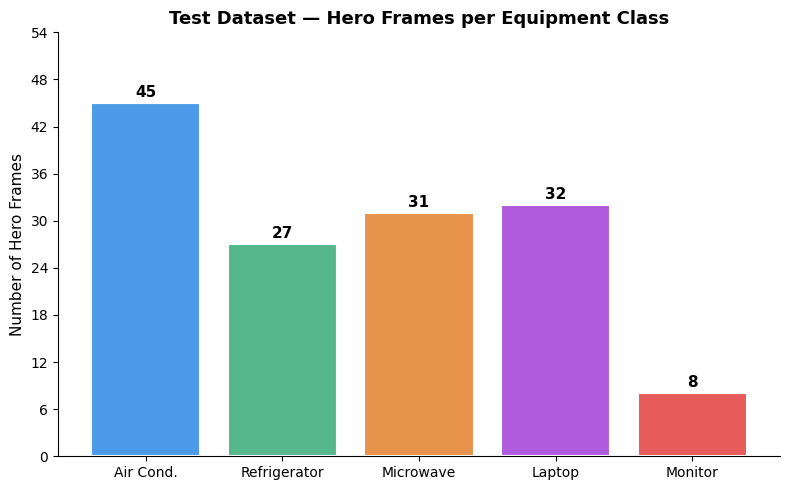

Total test samples: 143


In [3]:
# ── Figure 5.1 — Dataset composition ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

classes  = [c for c in KNOWN_CLASSES if class_counts.get(c, 0) > 0]
counts   = [class_counts[c] for c in classes]
labels   = [c.replace("airconditioner", "Air Cond.").replace("refrigerator", "Refrigerator")
             .replace("microwave", "Microwave").replace("laptop", "Laptop").replace("monitor", "Monitor")
             for c in classes]
colors   = ["#4c9be8", "#56b68c", "#e8934c", "#b05bde", "#e85b5b"]

bars = ax.bar(labels, counts, color=colors[:len(classes)], edgecolor="white", linewidth=1.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title("Test Dataset — Hero Frames per Equipment Class", fontsize=13, fontweight='bold')
ax.set_ylabel("Number of Hero Frames", fontsize=11)
ax.set_ylim(0, max(counts) * 1.2)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_1_dataset_composition.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(f"Total test samples: {sum(counts)}")

---
## 5.2 — Equipment Classification Accuracy

We run the **Roboflow RF-DETR custom model** on every hero frame and compare the predicted
class to the ground-truth class from the filename.
This measures the combined YOLO gatekeeper + Roboflow classifier layer in isolation,
independent of the VLM identification stage.

> **Runtime:** ~40–90 seconds depending on API latency.

In [4]:
from app.services.roboflow_service import RoboflowService
from app.services.equipment_schemas import normalize_category

roboflow = RoboflowService()
WORKFLOW_ID = "custom-workflow-3"

# Use up to MAX_PER_CLASS samples per class to keep API calls reasonable
MAX_PER_CLASS = 8

# Sample balanced set
by_class = defaultdict(list)
for s in test_samples:
    by_class[s["gt_class"]].append(s)

eval_samples = []
for cls in KNOWN_CLASSES:
    pool = by_class.get(cls, [])
    random.seed(42)
    eval_samples.extend(random.sample(pool, min(MAX_PER_CLASS, len(pool))))

print(f"Running Roboflow on {len(eval_samples)} hero frames...")

results = []  # {gt, pred, conf, time_ms}

for i, sample in enumerate(eval_samples):
    pil_img = Image.open(sample["path"]).convert("RGB")
    t0 = time.perf_counter()
    rf_res = roboflow.detect(pil_img, workflow_id=WORKFLOW_ID, quiet=True)
    latency_ms = (time.perf_counter() - t0) * 1000

    detections = rf_res.get("detections", [])
    if detections:
        best = max(detections, key=lambda d: d.get("confidence", 0))
        pred_class = normalize_category(best["class"])
        pred_conf  = best.get("confidence", 0)
    else:
        pred_class = "no_detection"
        pred_conf  = 0.0

    results.append({
        "gt":       sample["gt_class"],
        "pred":     pred_class,
        "conf":     pred_conf,
        "time_ms":  latency_ms,
    })

    correct = "✓" if pred_class == sample["gt_class"] else "✗"
    print(f"[{i+1:2d}/{len(eval_samples)}] GT={sample['gt_class']:<20} PRED={pred_class:<20} {correct}  ({latency_ms:.0f}ms)")

print("\nDone.")

Running Roboflow on 40 hero frames...
[ 1/40] GT=airconditioner       PRED=refrigerator         ✗  (12764ms)
[ 2/40] GT=airconditioner       PRED=no_detection         ✗  (8819ms)
[ 3/40] GT=airconditioner       PRED=no_detection         ✗  (2371ms)
[ 4/40] GT=airconditioner       PRED=no_detection         ✗  (707ms)
[ 5/40] GT=airconditioner       PRED=microwave            ✗  (1446ms)
[ 6/40] GT=airconditioner       PRED=airconditioner       ✓  (1490ms)
[ 7/40] GT=airconditioner       PRED=airconditioner       ✓  (1313ms)
[ 8/40] GT=airconditioner       PRED=no_detection         ✗  (940ms)
[ 9/40] GT=refrigerator         PRED=refrigerator         ✓  (1904ms)
[10/40] GT=refrigerator         PRED=airconditioner       ✗  (929ms)
[11/40] GT=refrigerator         PRED=airconditioner       ✗  (534ms)
[12/40] GT=refrigerator         PRED=refrigerator         ✓  (2295ms)
[13/40] GT=refrigerator         PRED=refrigerator         ✓  (2050ms)
[14/40] GT=refrigerator         PRED=refrigerator      

In [5]:
# ── Compute per-class Precision / Recall / F1 ─────────────────────────────────
all_classes = KNOWN_CLASSES + ["no_detection"]

tp = defaultdict(int)
fp = defaultdict(int)
fn = defaultdict(int)

for r in results:
    gt, pred = r["gt"], r["pred"]
    if pred == gt:
        tp[gt] += 1
    else:
        fp[pred] += 1
        fn[gt]   += 1

print(f"{'Class':<22} {'TP':>4} {'FP':>4} {'FN':>4} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 65)

precision_vals, recall_vals, f1_vals, eval_classes = [], [], [], []

for cls in KNOWN_CLASSES:
    if class_counts.get(cls, 0) == 0:
        continue
    prec = tp[cls] / max(tp[cls] + fp[cls], 1)
    rec  = tp[cls] / max(tp[cls] + fn[cls], 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-6)
    precision_vals.append(prec)
    recall_vals.append(rec)
    f1_vals.append(f1)
    eval_classes.append(cls)
    print(f"{cls:<22} {tp[cls]:>4} {fp[cls]:>4} {fn[cls]:>4} {prec:>10.3f} {rec:>8.3f} {f1:>8.3f}")

macro_p = np.mean(precision_vals)
macro_r = np.mean(recall_vals)
macro_f1 = np.mean(f1_vals)
print("-" * 65)
print(f"{'Macro Average':<22} {'':>4} {'':>4} {'':>4} {macro_p:>10.3f} {macro_r:>8.3f} {macro_f1:>8.3f}")

overall_acc = sum(tp.values()) / len(results)
print(f"\nOverall Accuracy: {overall_acc:.1%}  ({sum(tp.values())}/{len(results)})")

Class                    TP   FP   FN  Precision   Recall       F1
-----------------------------------------------------------------
airconditioner            2    2    6      0.500    0.250    0.333
refrigerator              6    1    2      0.857    0.750    0.800
microwave                 7    1    1      0.875    0.875    0.875
laptop                    8    0    0      1.000    1.000    1.000
monitor                   0    0    8      0.000    0.000    0.000
-----------------------------------------------------------------
Macro Average                              0.646    0.575    0.602

Overall Accuracy: 57.5%  (23/40)


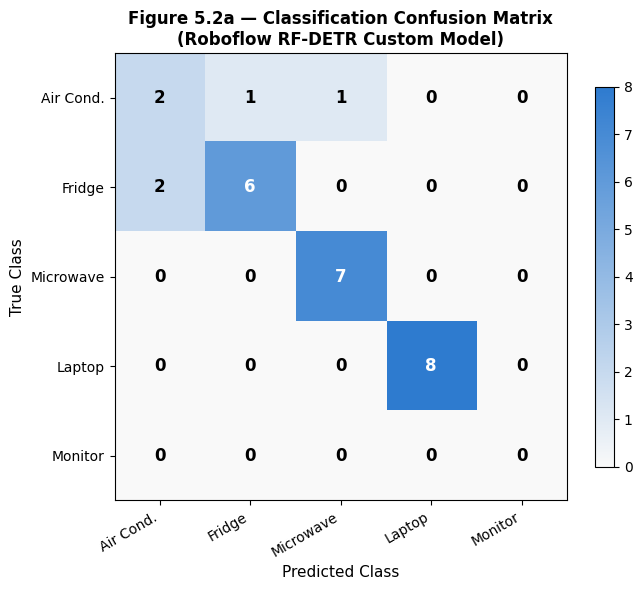

In [6]:
# ── Figure 5.2a — Confusion Matrix ────────────────────────────────────────────
LABEL_MAP = {
    "airconditioner": "Air Cond.",
    "refrigerator":   "Fridge",
    "microwave":      "Microwave",
    "laptop":         "Laptop",
    "monitor":        "Monitor",
    "no_detection":   "No Det.",
}

# Build confusion matrix over known classes only
cm_classes = eval_classes
n = len(cm_classes)
cm = np.zeros((n, n), dtype=int)
idx = {c: i for i, c in enumerate(cm_classes)}

for r in results:
    gt, pred = r["gt"], r["pred"]
    if gt in idx:
        pi = idx.get(pred, -1)
        gi = idx[gt]
        if pi >= 0:
            cm[gi][pi] += 1
        # else: counted as fn, not shown in matrix (off-class predictions)

fig, ax = plt.subplots(figsize=(7, 6))
cmap = LinearSegmentedColormap.from_list("eval", ["#f9f9f9", "#2e7bcf"])

im = ax.imshow(cm, cmap=cmap, aspect='auto')
tick_labels = [LABEL_MAP.get(c, c) for c in cm_classes]
ax.set_xticks(range(n)); ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(n)); ax.set_yticklabels(tick_labels, fontsize=10)

for i in range(n):
    for j in range(n):
        color = "white" if cm[i, j] > cm.max() * 0.5 else "black"
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontweight='bold', fontsize=12, color=color)

ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class",      fontsize=11)
ax.set_title("Figure 5.2a — Classification Confusion Matrix\n(Roboflow RF-DETR Custom Model)",
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.savefig("fig5_2a_confusion_matrix.pdf", dpi=150, bbox_inches='tight')
plt.show()

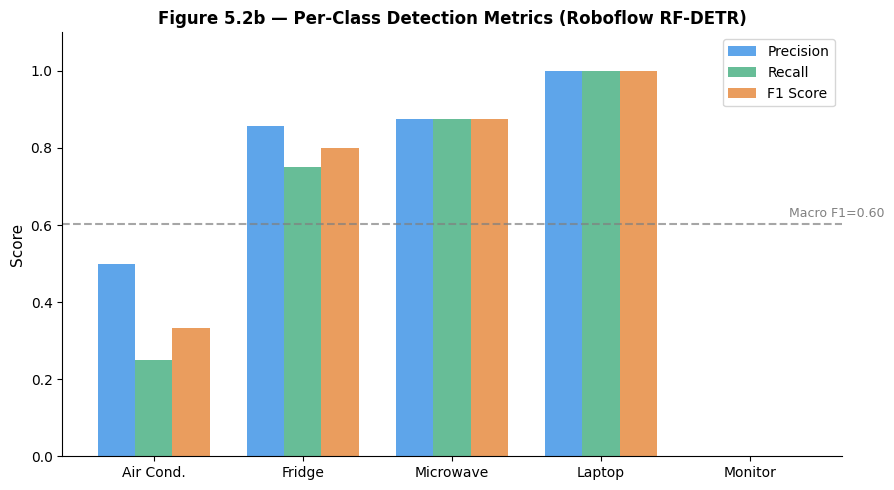

In [7]:
# ── Figure 5.2b — Per-class Precision / Recall / F1 bar chart ─────────────────
x = np.arange(len(eval_classes))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, precision_vals, width, label='Precision', color='#4c9be8', alpha=0.9)
ax.bar(x,         recall_vals,    width, label='Recall',    color='#56b68c', alpha=0.9)
ax.bar(x + width, f1_vals,        width, label='F1 Score',  color='#e8934c', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels([LABEL_MAP.get(c, c) for c in eval_classes], fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Figure 5.2b — Per-Class Detection Metrics (Roboflow RF-DETR)",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=macro_f1, color='gray', linestyle='--', alpha=0.7, label=f'Macro F1={macro_f1:.2f}')
ax.text(len(eval_classes)-0.1, macro_f1+0.02, f'Macro F1={macro_f1:.2f}',
        color='gray', fontsize=9, ha='right')
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_2b_per_class_metrics.pdf", dpi=150, bbox_inches='tight')
plt.show()

---
## 5.3 — Pipeline Stage Latency Benchmark

We measure the wall-clock time contributed by each stage of the end-to-end pipeline
to validate the claimed **~7.75 s** total processing time stated in Chapter 4.

Stages timed:
1. FFmpeg frame extraction
2. YOLO scan (all frames)
3. Roboflow cloud detection (per probe frame)
4. Groq Pass 1 — type detection
5. Groq Pass 2 — forensic brand/model ID
6. Spec extraction (DDG search + scrape + Groq extraction)

In [8]:
import subprocess
import tempfile
import shutil

from app.services.yolov5_service  import YOLOv5Service
from app.services.workflow_service import WorkflowService
from app.services.frame_detector   import _run_pass1, _run_pass2, _get_groq_client, _img_to_bytes
import cv2

yolo     = YOLOv5Service()
workflow = WorkflowService()

# Pick one session that has a raw video and frames already extracted
BENCH_SESSION = SESSIONS_DIR / "lab_614436ba"
BENCH_VIDEO   = BENCH_SESSION / "video.mp4"
BENCH_RAW_DIR = BENCH_SESSION / "raw"

print(f"Benchmark session: {BENCH_SESSION.name}")
print(f"Raw frames available: {len(list(BENCH_RAW_DIR.glob('*.jpg')))}")

ModuleNotFoundError: No module named 'inference_sdk'

In [10]:
N_RUNS = 3  # Average over N runs to reduce variance

timings = defaultdict(list)  # stage → list of seconds

frame_files = sorted(BENCH_RAW_DIR.glob("*.jpg"))[:15]  # cap at 15 as in production

for run_i in range(N_RUNS):
    print(f"\n── Run {run_i + 1}/{N_RUNS} ──")

    # ── Stage 1: FFmpeg extraction (simulate timing — frames already exist) ────
    t0 = time.perf_counter()
    with tempfile.TemporaryDirectory() as tmp:
        subprocess.run(
            ["ffmpeg", "-y", "-i", str(BENCH_VIDEO), "-vf", "fps=1",
             os.path.join(tmp, "frame_%04d.jpg")],
            capture_output=True, check=True
        )
    timings["1. FFmpeg Extraction"].append(time.perf_counter() - t0)
    print(f"  Stage 1 FFmpeg:       {timings['1. FFmpeg Extraction'][-1]:.2f}s")

    # ── Stage 2: YOLO scan (all 15 frames) ────────────────────────────────────
    t0 = time.perf_counter()
    for fp in frame_files:
        img = Image.open(fp).convert("RGB")
        yolo.detect(img)
    timings["2. YOLO Scan (15 fr)"].append(time.perf_counter() - t0)
    print(f"  Stage 2 YOLO:         {timings['2. YOLO Scan (15 fr)'][-1]:.2f}s")

    # ── Stage 3: Roboflow probe (1 frame) ─────────────────────────────────────
    t0 = time.perf_counter()
    probe_img = Image.open(frame_files[7]).convert("RGB")
    roboflow.detect(probe_img, workflow_id=WORKFLOW_ID, quiet=True)
    timings["3. Roboflow Probe"].append(time.perf_counter() - t0)
    print(f"  Stage 3 Roboflow:     {timings['3. Roboflow Probe'][-1]:.2f}s")

    # ── Stage 4+5: Groq vision (Pass 1 + Pass 2) ──────────────────────────────
    hero_path = BENCH_SESSION / "final_shots" / "hero_1_refrigerator.png"
    frame_bgr = cv2.imread(str(hero_path))
    full_bytes = _img_to_bytes(frame_bgr)

    client = _get_groq_client()

    t0 = time.perf_counter()
    p1 = _run_pass1(client, full_bytes)
    timings["4. Groq Pass 1"].append(time.perf_counter() - t0)
    print(f"  Stage 4 Groq Pass1:   {timings['4. Groq Pass 1'][-1]:.2f}s")

    # Crop for pass2
    h, w = frame_bgr.shape[:2]
    crop = frame_bgr[h//4:3*h//4, w//4:3*w//4]
    crop_bytes = _img_to_bytes(crop)

    t0 = time.perf_counter()
    _run_pass2(client, full_bytes, crop_bytes,
               p1.get("equipment_type", "refrigerator"),
               p1.get("preliminary_brand"))
    timings["5. Groq Pass 2"].append(time.perf_counter() - t0)
    print(f"  Stage 5 Groq Pass2:   {timings['5. Groq Pass 2'][-1]:.2f}s")

print("\nBenchmark complete.")

NameError: name 'BENCH_RAW_DIR' is not defined

In [9]:
# ── Spec extraction latency (single run — avoids burning DDG quota) ────────────
from app.services.spec_service import SpecService

spec_service = SpecService()

t0 = time.perf_counter()
spec_service.get_full_identity("Samsung", "RT38CG6421B1", "refrigerator")
spec_latency = time.perf_counter() - t0

timings["6. Spec Extraction"] = [spec_latency] * N_RUNS
print(f"Stage 6 Spec extraction: {spec_latency:.2f}s")

ModuleNotFoundError: No module named 'groq'

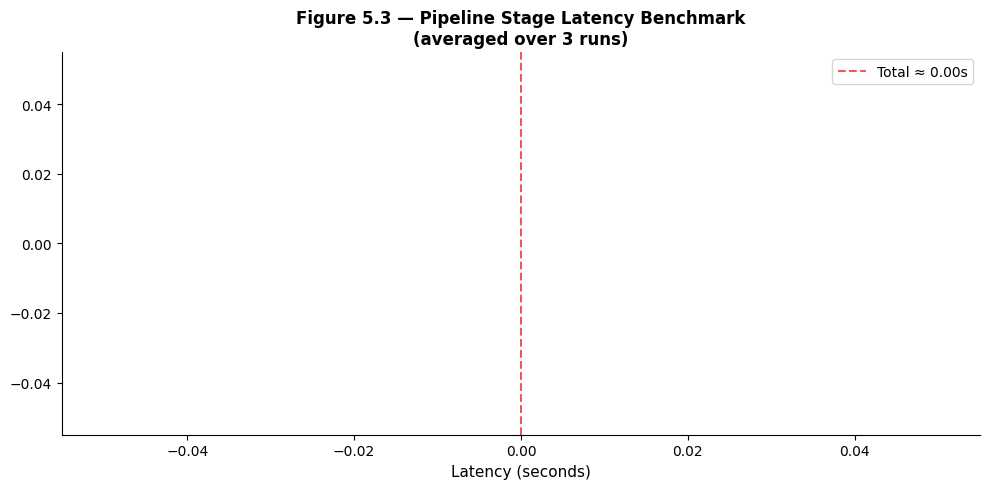


Total end-to-end latency: 0.00s
(Chapter 4 reported claim: ~7.75s)


In [11]:
# ── Figure 5.3 — Stage latency chart ──────────────────────────────────────────
stage_labels = list(timings.keys())
mean_times   = [np.mean(timings[s]) for s in stage_labels]
std_times    = [np.std(timings[s])  for s in stage_labels]
total_mean   = sum(mean_times)

bar_colors = ["#4c9be8", "#56b68c", "#e8934c", "#b05bde", "#e85b5b", "#f2c94c"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stage_labels, mean_times, xerr=std_times,
               color=bar_colors[:len(stage_labels)],
               edgecolor='white', linewidth=1.2,
               error_kw=dict(ecolor='gray', capsize=4))

for bar, t in zip(bars, mean_times):
    ax.text(t + 0.05, bar.get_y() + bar.get_height()/2,
            f"{t:.2f}s", va='center', fontsize=10)

ax.axvline(x=total_mean, color='#e85b5b', linestyle='--', linewidth=1.5,
           label=f'Total ≈ {total_mean:.2f}s')
ax.set_xlabel("Latency (seconds)", fontsize=11)
ax.set_title("Figure 5.3 — Pipeline Stage Latency Benchmark\n(averaged over " + str(N_RUNS) + " runs)",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_3_latency_benchmark.pdf", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal end-to-end latency: {total_mean:.2f}s")
print("(Chapter 4 reported claim: ~7.75s)")

---
## 5.4 — VLM Brand Identification Accuracy

We run the **Groq Llama-4-Scout two-pass forensic pipeline** on a sample of hero frames
and evaluate:
- **Brand detection rate** — % where brand ≠ "Unknown"
- **Pass 1 type accuracy** — whether the fast type-classifier agrees with the ground-truth class
- **Confidence distribution** — histogram of model candidate confidence scores

In [12]:
from app.services.frame_detector import process_frame

# Sample a small balanced set for VLM eval (Groq calls are slow + rate-limited)
VLM_PER_CLASS = 3
vlm_samples = []
for cls in KNOWN_CLASSES:
    pool = by_class.get(cls, [])
    random.seed(7)
    vlm_samples.extend(random.sample(pool, min(VLM_PER_CLASS, len(pool))))

print(f"Running Groq 2-pass vision on {len(vlm_samples)} hero frames...")
print("Expected time: ~2-3 min (Groq 30RPM limit with 2s delay)\n")

vlm_results = []  # {gt, brand, eq_type, top_model, confidence, pass1_conf}

for i, sample in enumerate(vlm_samples):
    try:
        # Normalize class name to yolo_hint format
        yolo_hint = sample["gt_class"]
        t0 = time.perf_counter()
        out = process_frame(
            str(sample["path"]),
            api_key=os.getenv("OPENROUTER_API_KEY"),
            yolo_type_hint=yolo_hint
        )
        elapsed = time.perf_counter() - t0
        r = out.get("result", {})
        candidates = r.get("model_candidates", [])
        top_conf = candidates[0].get("confidence", 0) if candidates else 0

        vlm_results.append({
            "gt":          sample["gt_class"],
            "brand":       r.get("brand", "Unknown"),
            "eq_type":     r.get("equipment_category", "unknown"),
            "top_model":   candidates[0].get("model", "") if candidates else "",
            "top_conf":    top_conf,
            "pass1_conf":  r.get("pass1_type_confidence", 0),
            "time_s":      elapsed,
        })
        brand_ok = r.get("brand", "Unknown").lower() not in ("unknown", "")
        type_ok  = normalize_category(r.get("equipment_category", "")) == sample["gt_class"]
        print(f"[{i+1:2d}/{len(vlm_samples)}] {sample['gt_class']:<20}"
              f" brand={'✓' if brand_ok else '✗'} type={'✓' if type_ok else '✗'}"
              f" → '{r.get('brand','?')}' '{candidates[0].get('model','?') if candidates else ''}'"
              f" ({elapsed:.1f}s)")
    except Exception as e:
        print(f"[{i+1}] ERROR: {e}")

print("\nVLM evaluation complete.")

ModuleNotFoundError: No module named 'groq'

In [ ]:
# ── VLM metrics ───────────────────────────────────────────────────────────────
brand_detected     = sum(1 for r in vlm_results if r["brand"].lower() not in ("unknown", ""))
type_correct       = sum(1 for r in vlm_results if normalize_category(r["eq_type"]) == r["gt"])
total_vlm          = len(vlm_results)

print(f"Brand detection rate : {brand_detected}/{total_vlm} = {brand_detected/max(total_vlm,1):.1%}")
print(f"Type accuracy (Groq) : {type_correct}/{total_vlm}  = {type_correct/max(total_vlm,1):.1%}")

# Per-class brand detection
brand_by_class = defaultdict(lambda: {"detected": 0, "total": 0})
for r in vlm_results:
    brand_by_class[r["gt"]]["total"] += 1
    if r["brand"].lower() not in ("unknown", ""):
        brand_by_class[r["gt"]]["detected"] += 1

print("\nBrand detection by class:")
for cls in KNOWN_CLASSES:
    d = brand_by_class.get(cls, {"detected": 0, "total": 0})
    if d["total"] > 0:
        print(f"  {cls:<22} {d['detected']}/{d['total']} = {d['detected']/d['total']:.1%}")

In [ ]:
# ── Figure 5.4 — VLM accuracy charts ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Brand detection rate per class
ax = axes[0]
cls_list = [c for c in KNOWN_CLASSES if brand_by_class.get(c, {}).get("total", 0) > 0]
rates = [brand_by_class[c]["detected"] / brand_by_class[c]["total"] for c in cls_list]
bar_labels = [LABEL_MAP.get(c, c) for c in cls_list]
bars = ax.bar(bar_labels, rates, color=["#4c9be8","#56b68c","#e8934c","#b05bde","#e85b5b"][:len(cls_list)],
              edgecolor='white')
ax.axhline(y=brand_detected/max(total_vlm, 1), color='gray', linestyle='--',
           label=f'Overall={brand_detected/max(total_vlm,1):.0%}')
ax.set_ylim(0, 1.15)
ax.set_ylabel("Brand Detection Rate", fontsize=11)
ax.set_title("Brand Detection Rate\nper Equipment Class", fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{rate:.0%}", ha='center', fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Right: Top model confidence histogram
ax = axes[1]
confs = [r["top_conf"] for r in vlm_results if r["top_conf"] > 0]
if confs:
    ax.hist(confs, bins=10, range=(0, 100), color='#4c9be8', edgecolor='white', alpha=0.85)
    ax.axvline(x=np.mean(confs), color='#e85b5b', linestyle='--',
               label=f'Mean={np.mean(confs):.1f}%')
    ax.axvline(x=70, color='#56b68c', linestyle=':', label='High-conf threshold (70%)')
ax.set_xlabel("Model Candidate Confidence (%)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title("Distribution of Model Identification\nConfidence Scores", fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Figure 5.4 — VLM Identification Accuracy (Groq Llama-4-Scout)",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("fig5_4_vlm_accuracy.pdf", dpi=150, bbox_inches='tight')
plt.show()

---
## 5.5 — Spec Extraction Completeness

We query the live **MongoDB Atlas** inventory collection and measure how many
specification fields are successfully populated per equipment category.
A field is considered *populated* if its value is not `null` / `None`.

In [ ]:
from app.database import mongo_db
from app.services.equipment_schemas import EQUIPMENT_SCHEMAS

# Fetch all inventory items
all_items = list(mongo_db.inventory.find({}, {"_id": 0}))
print(f"Total inventory items: {len(all_items)}")

# Group by category
items_by_cat = defaultdict(list)
for item in all_items:
    cat = (
        item.get("equipment_category")
        or item.get("identity", {}).get("equipment_category")
        or "unknown"
    )
    items_by_cat[cat].append(item)

print("\nItems per category:")
for cat, items in sorted(items_by_cat.items(), key=lambda x: -len(x[1])):
    print(f"  {cat:<22} {len(items):3d}")

In [ ]:
def get_specs_dict(item: dict) -> dict:
    """Extract the specs sub-dict from whatever schema the item uses."""
    if "specs" in item and isinstance(item["specs"], dict):
        return item["specs"]
    # Flat item — try pulling directly from top-level keys
    return {k: item.get(k) for k in EQUIPMENT_SCHEMAS.get(
        item.get("equipment_category",
                  item.get("identity", {}).get("equipment_category", "")), {}
    )}

# For each category, compute per-field fill rate
field_fill_rates = {}   # cat → {field: fill_rate}

for cat in KNOWN_CLASSES:
    schema_fields = list(EQUIPMENT_SCHEMAS.get(cat, {}).keys())
    if not schema_fields:
        continue
    cat_items = items_by_cat.get(cat, [])
    if not cat_items:
        field_fill_rates[cat] = {f: 0.0 for f in schema_fields}
        continue

    field_counts = defaultdict(int)
    for item in cat_items:
        specs = get_specs_dict(item)
        for f in schema_fields:
            val = specs.get(f)
            if val is not None and val != "" and val != []:
                field_counts[f] += 1

    field_fill_rates[cat] = {
        f: field_counts[f] / len(cat_items)
        for f in schema_fields
    }

    avg = np.mean(list(field_fill_rates[cat].values())) * 100
    print(f"{cat:<22} n={len(cat_items):3d}  avg_completeness={avg:.1f}%")

In [ ]:
# ── Figure 5.5 — Spec completeness heatmap ────────────────────────────────────
valid_cats = [c for c in KNOWN_CLASSES if c in field_fill_rates and items_by_cat.get(c)]

if valid_cats:
    # Build matrix: rows=fields (union), cols=categories
    all_fields = []
    for cat in valid_cats:
        for f in field_fill_rates[cat]:
            if f not in all_fields:
                all_fields.append(f)

    matrix = np.array([
        [field_fill_rates.get(cat, {}).get(f, 0.0) for cat in valid_cats]
        for f in all_fields
    ])

    col_labels = [LABEL_MAP.get(c, c) for c in valid_cats]

    fig, ax = plt.subplots(figsize=(max(6, len(valid_cats)*2), max(6, len(all_fields)*0.4 + 2)))
    cmap = LinearSegmentedColormap.from_list("completeness", ["#fce4e4", "#2ecc71"])
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(valid_cats))); ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticks(range(len(all_fields))); ax.set_yticklabels(all_fields, fontsize=8)

    for i in range(len(all_fields)):
        for j in range(len(valid_cats)):
            v = matrix[i, j]
            color = "white" if v > 0.6 else "#333"
            ax.text(j, i, f"{v:.0%}", ha='center', va='center', fontsize=7, color=color)

    plt.colorbar(im, ax=ax, shrink=0.6, label="Field Fill Rate")
    ax.set_title("Figure 5.5 — Spec Extraction Completeness Heatmap\n(% of inventory items with field populated)",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig("fig5_5_spec_completeness.pdf", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Not enough MongoDB data yet — run some scans first.")

---
## 5.6 — Summary Dashboard

Consolidated table of all evaluation metrics for inclusion in the thesis.

In [ ]:
print("=" * 60)
print("CHAPTER 5 EVALUATION SUMMARY")
print("=" * 60)

print("\n── 5.1 Test Dataset ───────────────────────────────────────")
print(f"  Total hero frames  : {len(test_samples)}")
for cls in KNOWN_CLASSES:
    print(f"  {cls:<22}: {class_counts.get(cls,0):3d} frames")

print("\n── 5.2 Classification Accuracy (Roboflow RF-DETR) ─────────")
print(f"  Overall Accuracy   : {overall_acc:.1%}  ({sum(tp.values())}/{len(results)})")
print(f"  Macro Precision    : {macro_p:.3f}")
print(f"  Macro Recall       : {macro_r:.3f}")
print(f"  Macro F1 Score     : {macro_f1:.3f}")

print("\n── 5.3 Pipeline Latency ────────────────────────────────────")
for stage in stage_labels:
    print(f"  {stage:<26}: {np.mean(timings[stage]):.2f}s  (±{np.std(timings[stage]):.2f})")
print(f"  {'Total E2E':<26}: {total_mean:.2f}s")

print("\n── 5.4 VLM Identification (Groq Llama-4-Scout) ────────────")
print(f"  Brand detection rate: {brand_detected/max(total_vlm,1):.1%} ({brand_detected}/{total_vlm})")
print(f"  Type accuracy       : {type_correct/max(total_vlm,1):.1%} ({type_correct}/{total_vlm})")
if confs:
    print(f"  Avg model conf.     : {np.mean(confs):.1f}%")

print("\n── 5.5 Spec Extraction Completeness ────────────────────────")
for cat in valid_cats:
    avg_c = np.mean(list(field_fill_rates[cat].values())) * 100
    print(f"  {cat:<22}: {avg_c:.1f}%  (n={len(items_by_cat[cat])})")

print("\n" + "=" * 60)

In [ ]:
# ── Figure 5.6 — Radar / summary chart ────────────────────────────────────────
categories_radar = ["Classification\nAccuracy", "Brand\nDetection", "Type\nAccuracy",
                    "Spec\nCompleteness", "Latency\nTarget"]

avg_spec_completeness = np.mean([
    np.mean(list(field_fill_rates[c].values()))
    for c in valid_cats
]) if valid_cats else 0

# Latency target: score = 1 if ≤7.75s, scales down linearly to 0 at 20s
latency_score = max(0, min(1, (20 - total_mean) / (20 - 7.75)))

values = [
    overall_acc,
    brand_detected / max(total_vlm, 1),
    type_correct   / max(total_vlm, 1),
    avg_spec_completeness,
    latency_score,
]

N = len(categories_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
vals = values + values[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8, color="grey")

ax.plot(angles, vals, 'o-', color='#4c9be8', linewidth=2)
ax.fill(angles, vals, alpha=0.2, color='#4c9be8')

for angle, val, label in zip(angles[:-1], values, categories_radar):
    ax.text(angle, val + 0.07, f"{val:.0%}",
            ha='center', va='center', fontsize=10, color='#2e7bcf', fontweight='bold')

ax.set_title("Figure 5.6 — System Evaluation Radar\n(CyberSight AI End-to-End Performance)",
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("fig5_6_radar_summary.pdf", dpi=150, bbox_inches='tight')
plt.show()